# 03 -- Exploratory Data Analysis

**Project:** SuperStore Retail Performance & Profitability Analysis  
**Workflow:** EDA on the cleaned 37-column Tableau dataset  
**Goal:** Surface the business patterns that should drive the Tableau dashboard pages, KPIs, slicers, and chart selection.

## 1. Environment Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "SuperStore_Analysis/Tableau_Analysis/scripts/superstore_pipeline.py").exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root from the notebook environment.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SuperStore_Analysis.Tableau_Analysis.scripts.superstore_pipeline import (
    FINAL_SCHEMA,
    LOYAL_CUSTOMER_MIN_PURCHASES,
    build_clean_dataset,
    build_tableau_ready_dataset,
    compute_project_metrics,
    copy_raw_snapshot,
    export_pipeline_outputs,
    load_existing_cleaned_dataset,
    load_raw_dataset,
    prepare_analysis_frame,
    resolve_project_paths,
    validate_final_schema,
)

PATHS = resolve_project_paths(REPO_ROOT / "SuperStore_Analysis" / "Tableau_Analysis")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


## 2. Load the Final Cleaned Dataset

In [2]:
df = pd.read_csv(PATHS.cleaned_output_path)
df = prepare_analysis_frame(df)
overview = pd.DataFrame({
    "Metric": ["Rows", "Sales", "Profit", "Profit Margin", "Quantity", "Loss Transactions", "Average Discount"],
    "Value": [
        len(df),
        f"${df['Sales'].sum():,.2f}",
        f"${df['Profit'].sum():,.2f}",
        f"{(df['Profit'].sum() / df['Sales'].sum()) * 100:.2f}%",
        int(df['Quantity'].sum()),
        int((df['Loss Flag'] == 'Loss').sum()),
        f"{df['Discount Rate'].mean() * 100:.2f}%",
    ],
})
display(overview)


,Metric,Value
0,Rows,9993
1,Sales,"$2,296,919.28"
2,Profit,"$286,408.60"
3,Profit Margin,12.47%
4,Quantity,37871
5,Loss Transactions,1870
6,Average Discount,15.62%


## 3. Univariate Analysis

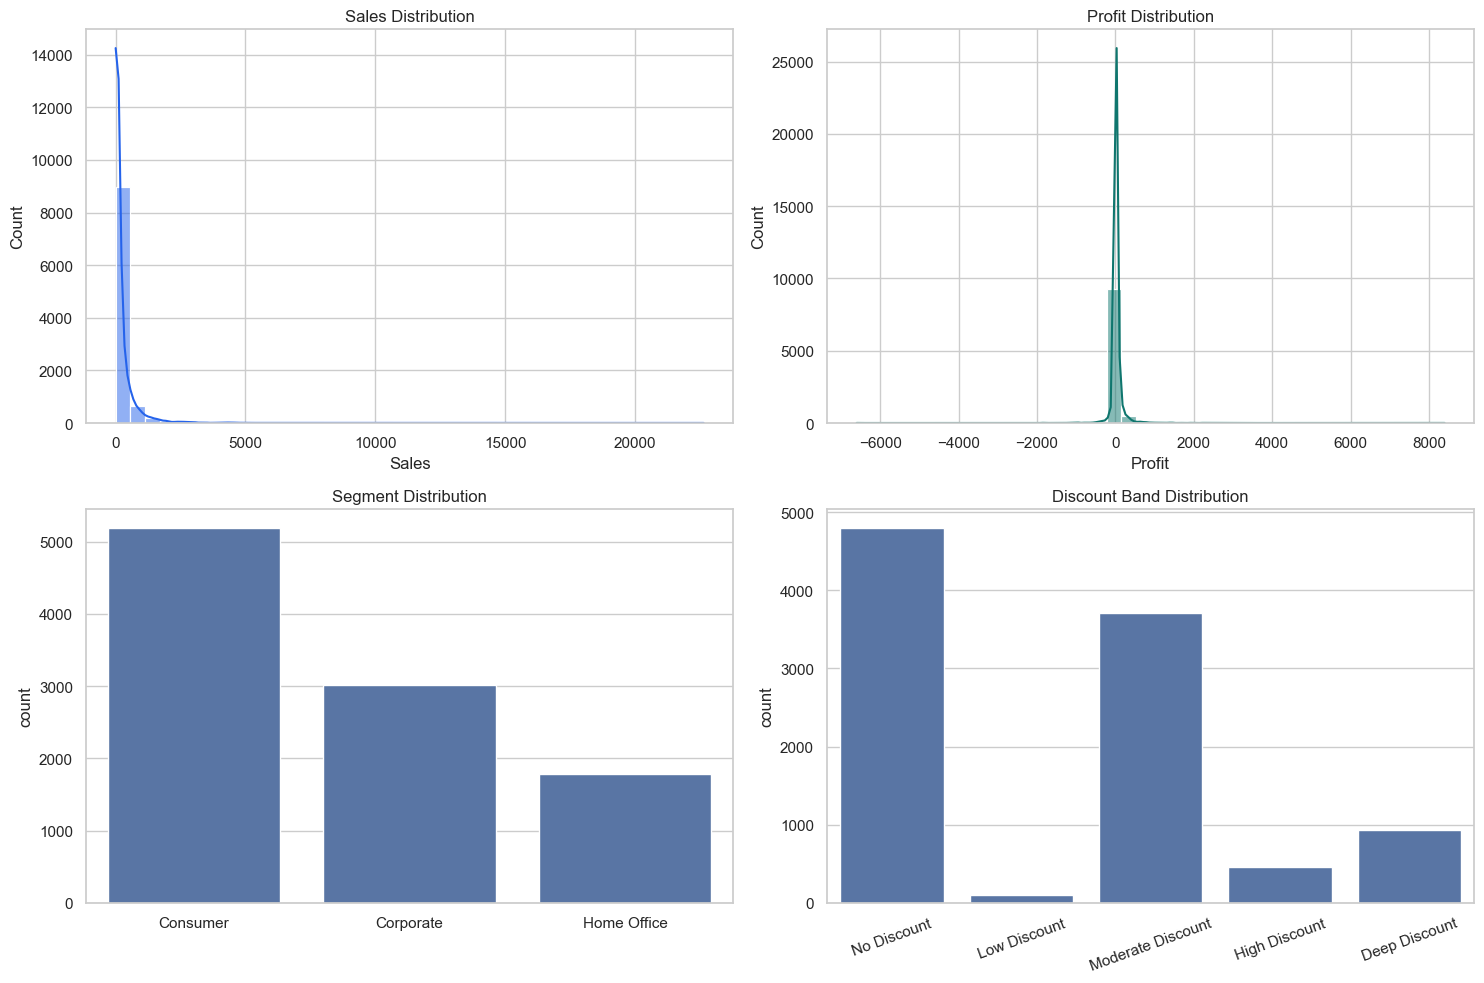

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['Sales'], bins=40, kde=True, ax=axes[0, 0], color='#2563eb')
axes[0, 0].set_title('Sales Distribution')

sns.histplot(df['Profit'], bins=40, kde=True, ax=axes[0, 1], color='#0f766e')
axes[0, 1].set_title('Profit Distribution')

sns.countplot(data=df, x='Segment', order=['Consumer', 'Corporate', 'Home Office'], ax=axes[1, 0])
axes[1, 0].set_title('Segment Distribution')
axes[1, 0].set_xlabel('')

discount_band_order = ['No Discount', 'Low Discount', 'Moderate Discount', 'High Discount', 'Deep Discount']
sns.countplot(data=df, x='Discount Band', order=discount_band_order, ax=axes[1, 1])
axes[1, 1].set_title('Discount Band Distribution')
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()


## 4. Category and Region Performance

,Sales,Profit,Profit Margin %
Category,,,
TECHNOLOGY,"836,154.02","145,455.44",17.40
FURNITURE,"741,718.36","18,463.16",2.49
OFFICE SUPPLIES,"719,046.90","122,490.00",17.04


,Sales,Profit,Profit Margin %
Region,,,
West,"725,457.76","108,418.31",14.94
East,"678,499.93","91,534.56",13.49
Central,"501,239.76","39,706.24",7.92
South,"391,721.83","46,749.49",11.93


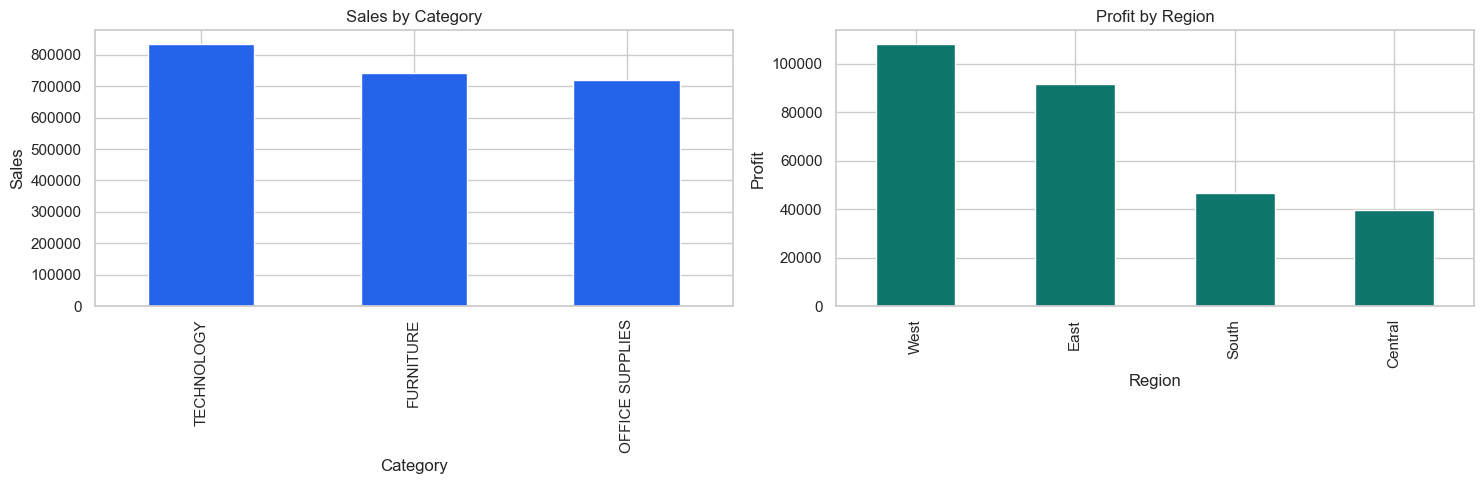

In [4]:
category_summary = df.groupby('Category').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
category_summary['Profit Margin %'] = (category_summary['Profit'] / category_summary['Sales'] * 100).round(2)
region_summary = df.groupby('Region').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
region_summary['Profit Margin %'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)

display(category_summary.sort_values('Sales', ascending=False).round(2))
display(region_summary.sort_values('Sales', ascending=False).round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
category_summary['Sales'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#2563eb')
axes[0].set_title('Sales by Category')
axes[0].set_ylabel('Sales')
region_summary['Profit'].sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#0f766e')
axes[1].set_title('Profit by Region')
axes[1].set_ylabel('Profit')
plt.tight_layout()
plt.show()


## 5. Sub-Category Profitability

,Sales,Profit
Sub-Category,,
Tables,"206,965.53","-17,725.57"
Bookcases,"114,879.98","-3,472.59"
Supplies,"46,673.52","-1,189.08"
Fasteners,"3,024.25",949.52
Machines,"189,238.60","3,384.72"
Labels,"12,486.30","5,546.18"
Art,"27,118.80","6,527.84"
Envelopes,"16,476.38","6,964.06"


,Sales,Profit
Sub-Category,,
Copiers,"149,528.01","55,617.88"
Phones,"330,007.10","44,516.06"
Accessories,"167,380.31","41,936.78"
Paper,"78,479.24","34,053.11"
Binders,"203,412.68","30,221.48"
Chairs,"328,167.73","26,602.14"
Storage,"223,843.59","21,278.90"
Appliances,"107,532.14","18,137.99"


/var/folders/lx/6dh93vr13sz9t2b72wypqh5m0000gn/T/ipykernel_37914/865898454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y='Sub-Category', x='Profit', palette=palette)


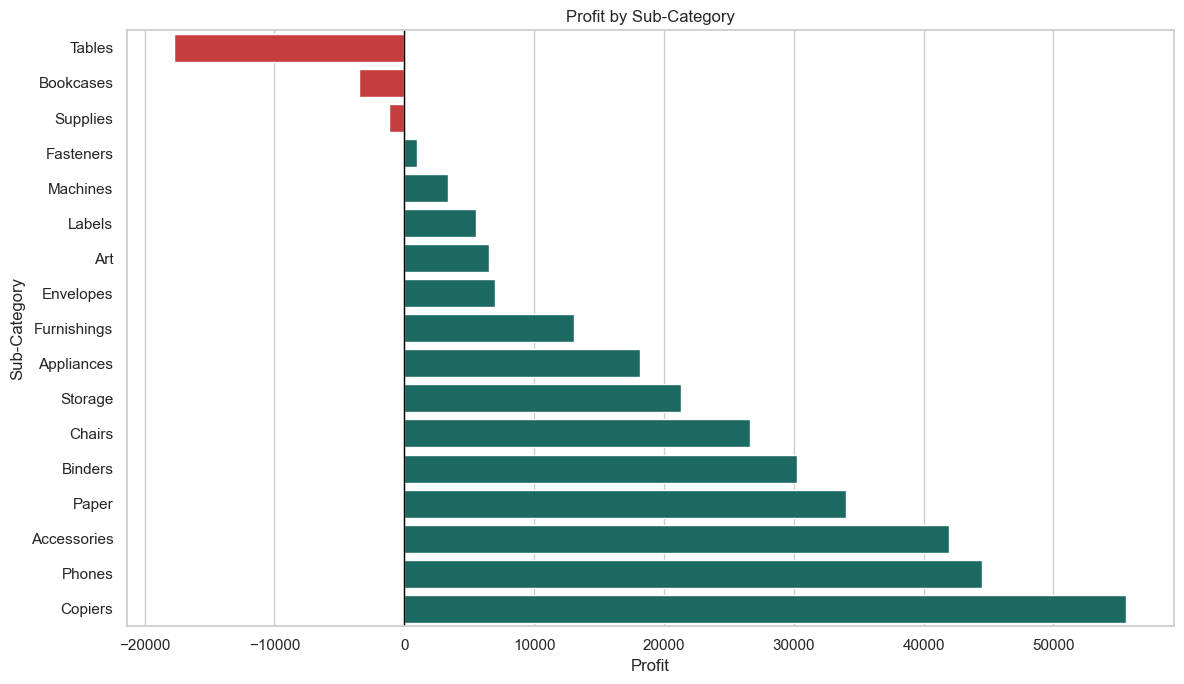

In [5]:
subcategory_summary = df.groupby('Sub-Category').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).sort_values('Profit')
display(subcategory_summary.head(8).round(2))
display(subcategory_summary.tail(8).sort_values('Profit', ascending=False).round(2))

plt.figure(figsize=(12, 7))
plot_df = subcategory_summary.reset_index()
palette = ['#dc2626' if value < 0 else '#0f766e' for value in plot_df['Profit']]
sns.barplot(data=plot_df, y='Sub-Category', x='Profit', palette=palette)
plt.axvline(0, color='black', linewidth=1)
plt.title('Profit by Sub-Category')
plt.tight_layout()
plt.show()


## 6. Time-Series Analysis

,Year Quarter,Sales,Profit
0,2014 Q1,"74,447.84","3,811.17"
1,2014 Q2,"86,257.37","11,216.16"
2,2014 Q3,"143,633.16","12,804.67"
3,2014 Q4,"179,627.73","21,723.92"
4,2015 Q1,"68,851.74","9,264.93"
5,2015 Q2,"89,124.27","12,190.90"
6,2015 Q3,"130,259.48","16,853.62"
7,2015 Q4,"182,296.90","23,308.99"
8,2016 Q1,"93,237.19","11,441.35"
9,2016 Q2,"136,082.29","16,390.26"


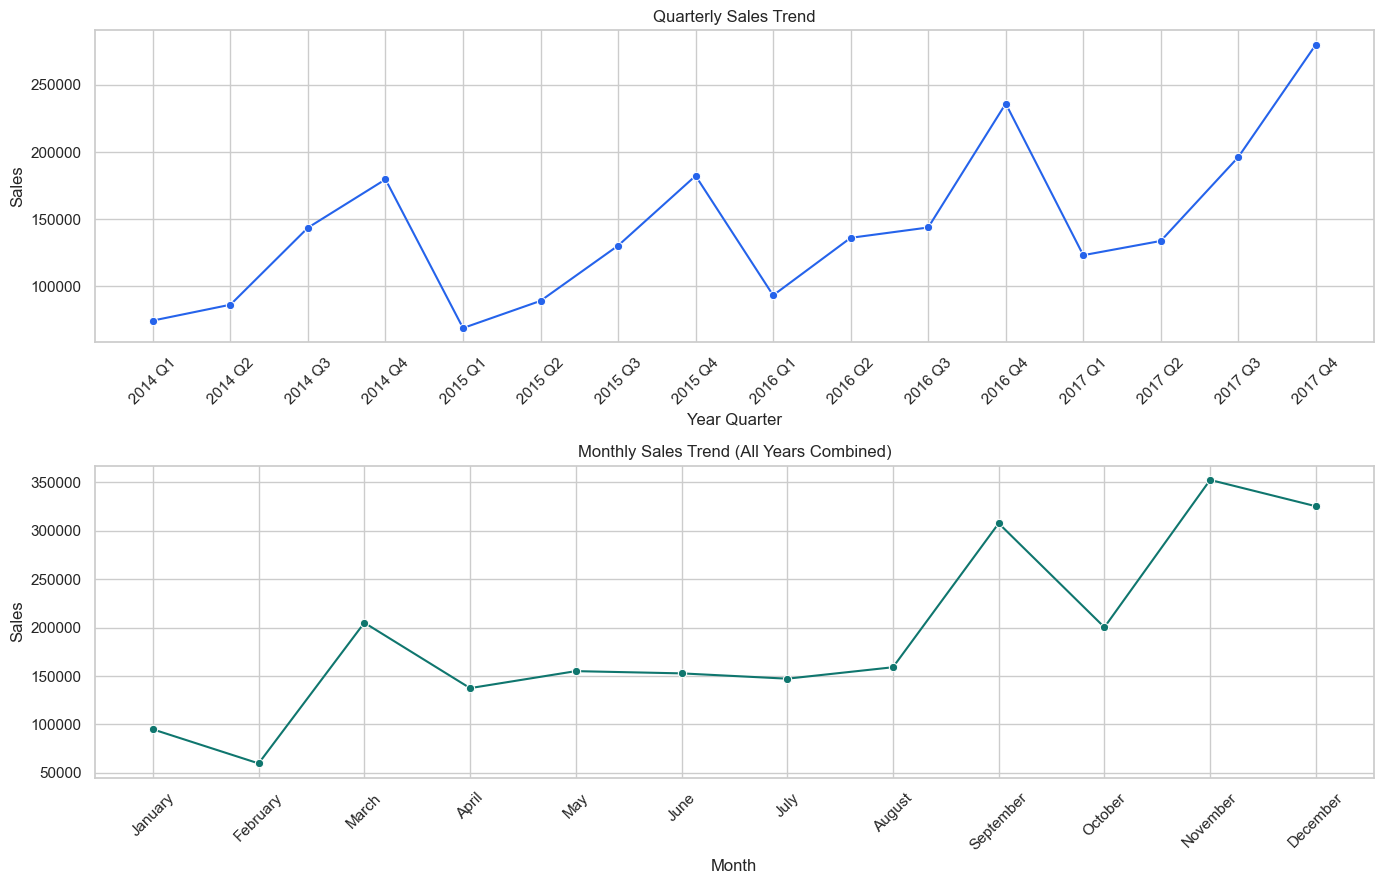

In [6]:
quarterly = df.groupby(['Year Quarter Sort', 'Year Quarter']).agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index().sort_values('Year Quarter Sort')
monthly = df.groupby(['Month Number', 'Month']).agg(Sales=('Sales', 'sum')).reset_index().sort_values('Month Number')

display(quarterly[['Year Quarter', 'Sales', 'Profit']].round(2))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
sns.lineplot(data=quarterly, x='Year Quarter', y='Sales', marker='o', ax=axes[0], color='#2563eb')
axes[0].set_title('Quarterly Sales Trend')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(data=monthly, x='Month', y='Sales', marker='o', ax=axes[1], color='#0f766e')
axes[1].set_title('Monthly Sales Trend (All Years Combined)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 7. Discount and Profitability Relationship

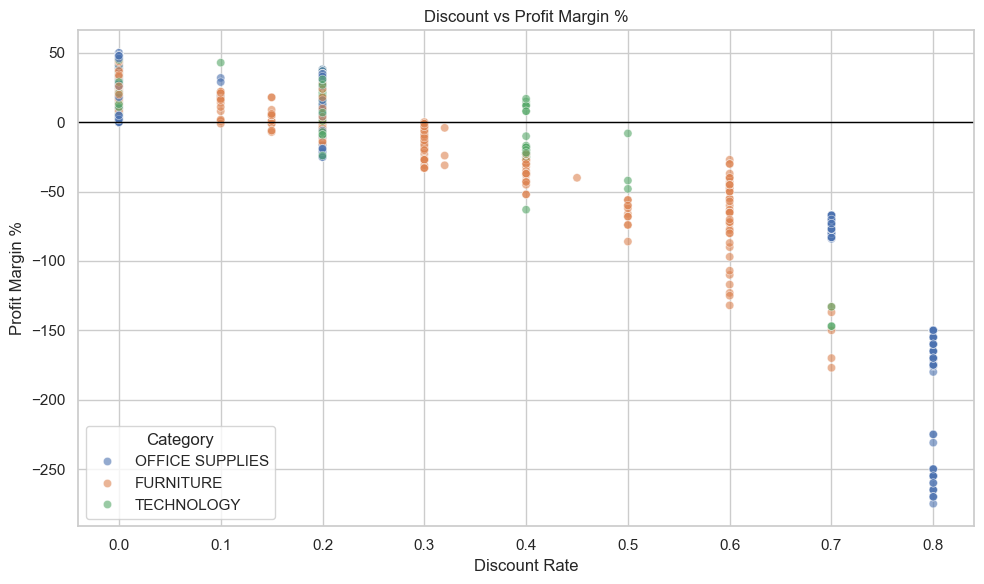

Loss Flag,Loss,Profit
Discount Band,,
Deep Discount,100.00,0.00
High Discount,90.20,9.80
Low Discount,4.26,95.74
Moderate Discount,13.99,86.01
No Discount,0.00,100.00


In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(len(df), 3000), random_state=42), x='Discount Rate', y='Profit Margin %', hue='Category', alpha=0.6)
plt.axhline(0, color='black', linewidth=1)
plt.title('Discount vs Profit Margin %')
plt.xlabel('Discount Rate')
plt.ylabel('Profit Margin %')
plt.tight_layout()
plt.show()

loss_by_discount = pd.crosstab(df['Discount Band'], df['Loss Flag'], normalize='index').mul(100).round(2)
display(loss_by_discount)


## 8. Multivariate Analysis

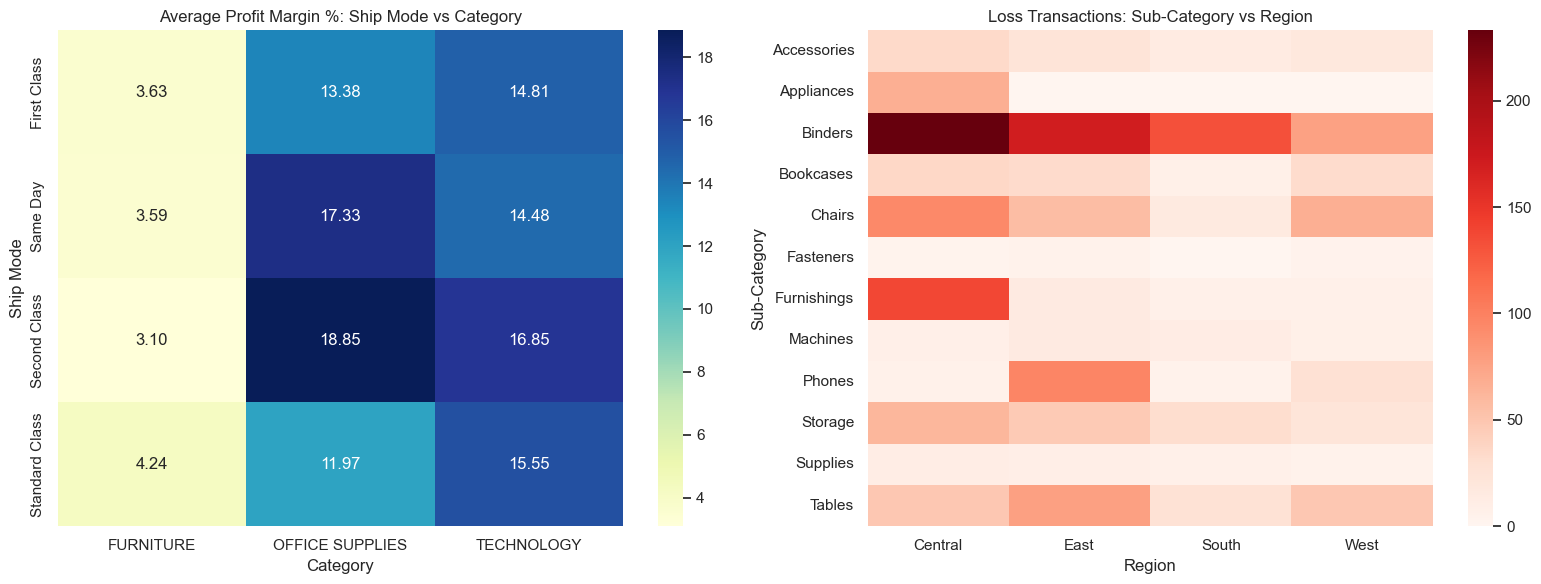

In [8]:
heatmap_df = pd.pivot_table(
    df,
    values='Profit Margin %',
    index='Ship Mode',
    columns='Category',
    aggfunc='mean',
)
loss_region = pd.pivot_table(
    df[df['Loss Flag'] == 'Loss'],
    values='Transaction Id (PK)',
    index='Sub-Category',
    columns='Region',
    aggfunc='count',
    fill_value=0,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(heatmap_df.round(2), annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Average Profit Margin %: Ship Mode vs Category')

sns.heatmap(loss_region, cmap='Reds', ax=axes[1])
axes[1].set_title('Loss Transactions: Sub-Category vs Region')
plt.tight_layout()
plt.show()


## 9. EDA Takeaways

- Technology and Office Supplies are the strongest profit generators, while Furniture has clear profit leakage.
- Tables and Bookcases are the most problematic sub-categories from a margin perspective.
- The sharp rise in loss rates above the 20% discount threshold should become a central story in the Tableau dashboard.
- Quarter and month trends show strong seasonality, especially in Q4 and the late-year months.